In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel("C:/Users/Admin/Desktop/marketing funnel and conversion/MARKET FUNNEL.xlsx")  # change path if needed

df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595379968,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326769920,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792630016,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920209920,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631879936,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [5]:
# Convert to datetime
df['event_time'] = pd.to_datetime(df['event_time'], errors='coerce')

# Remove missing values
df = df.dropna(subset=['event_type', 'user_id'])

# Create Date column
df['Date'] = df['event_time'].dt.date

df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,Date
0,2019-10-01 00:00:00+00:00,view,44600062,2103807459595379968,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c,2019-10-01
1,2019-10-01 00:00:00+00:00,view,3900821,2053013552326769920,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc,2019-10-01
2,2019-10-01 00:00:01+00:00,view,17200506,2053013559792630016,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8,2019-10-01
3,2019-10-01 00:00:01+00:00,view,1307067,2053013558920209920,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713,2019-10-01
4,2019-10-01 00:00:04+00:00,view,1004237,2053013555631879936,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,2019-10-01


In [6]:
#funnel calculation
visitors = df[df['event_type'] == 'view']['user_id'].nunique()
leads = df[df['event_type'] == 'cart']['user_id'].nunique()
customers = df[df['event_type'] == 'purchase']['user_id'].nunique()

print("Visitors:", visitors)
print("Leads:", leads)
print("Customers:", customers)

Visitors: 168868
Leads: 7880
Customers: 12774


In [7]:
#conversion rate
traffic_to_lead = (leads / visitors) * 100 if visitors != 0 else 0
lead_to_customer = (customers / leads) * 100 if leads != 0 else 0

print(f"Traffic to Lead: {traffic_to_lead:.2f}%")
print(f"Lead to Customer: {lead_to_customer:.2f}%")

Traffic to Lead: 4.67%
Lead to Customer: 162.11%


In [12]:
#drop off analysis
drop_visitors_leads = visitors - leads
drop_leads_customers = leads - customers

print("Drop-off (Visitors → Leads):", drop_visitors_leads)
print("Drop-off (Leads → Customers):", drop_leads_customers)

Drop-off (Visitors → Leads): 160988
Drop-off (Leads → Customers): -4894


In [14]:
#category performance
category_counts = df[df['event_type'] == 'purchase']['category_code'].value_counts().head(5)

category_counts

category_code
electronics.smartphone         8110
electronics.audio.headphone     798
electronics.video.tv            460
electronics.clocks              434
computers.notebook              416
Name: count, dtype: int64

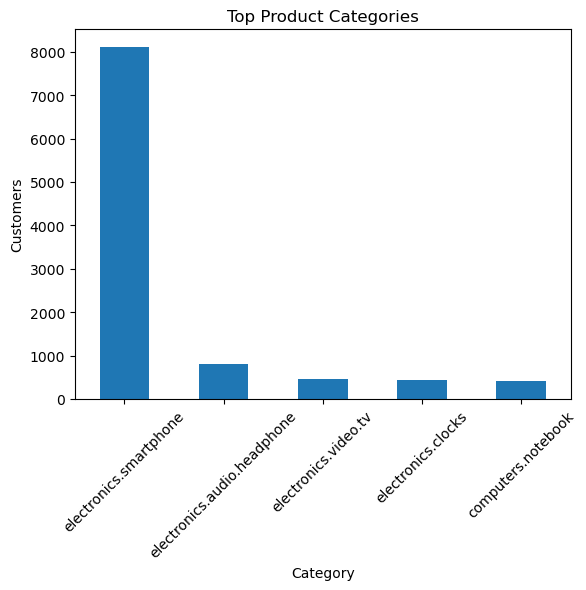

In [16]:
#plotting top product category
category_counts.plot(kind='bar')

plt.title("Top Product Categories")
plt.xlabel("Category")
plt.ylabel("Customers")
plt.xticks(rotation=45)
plt.show()

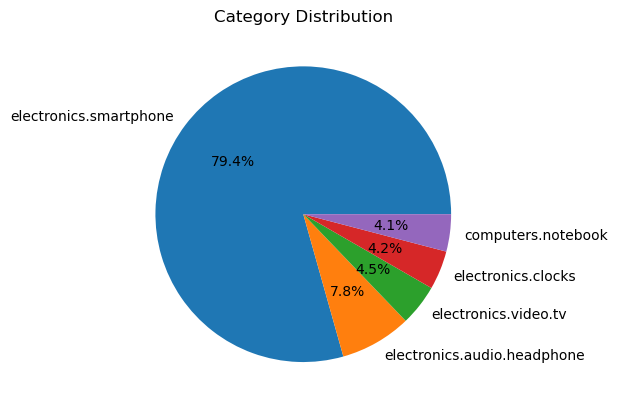

In [18]:
#plotting a pie chart
category_counts.plot(kind='pie', autopct='%1.1f%%')

plt.title("Category Distribution")
plt.ylabel("")
plt.show()

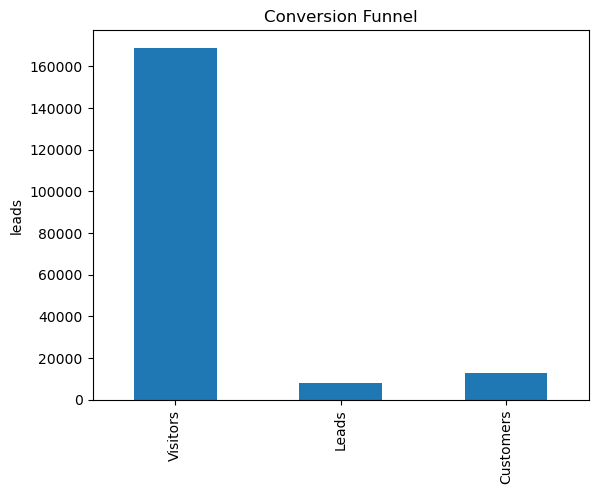

In [22]:
#plotting conversion funnel
funnel = pd.Series([visitors, leads, customers],
                   index=['Visitors', 'Leads', 'Customers'])

funnel.plot(kind='bar')

plt.title("Conversion Funnel")
plt.ylabel("leads")
plt.show()

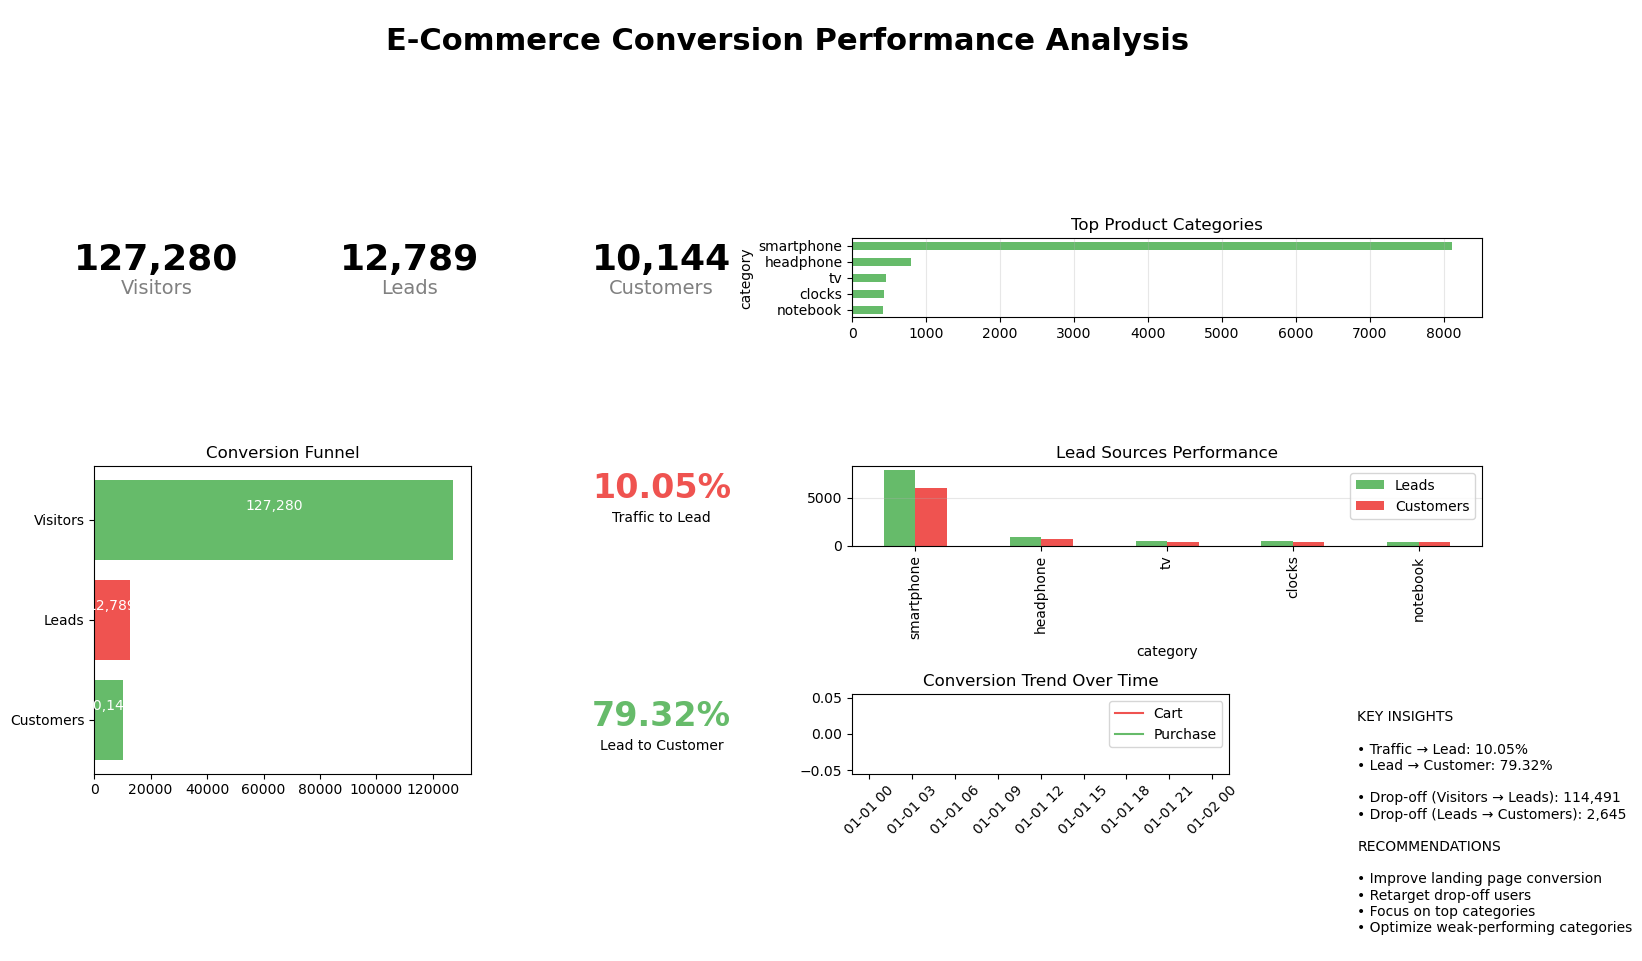

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_excel("C:/Users/Admin/Desktop/marketing funnel and conversion/MARKET FUNNEL.xlsx")

# -----------------------------
# CLEAN DATA
# -----------------------------
df['event_time'] = df['event_time'].astype(str).str.replace(" UTC", "")
df['event_time'] = pd.to_datetime(df['event_time'], errors='coerce')

df = df.dropna(subset=['event_type', 'user_id'])

df['Date'] = df['event_time'].dt.date

# Clean categories
df['category_code'] = df['category_code'].fillna("unknown").str.lower()
df['category'] = df['category_code'].apply(lambda x: x.split('.')[-1])

# ❌ Remove "unknown"
df = df[df['category'] != 'unknown']

# -----------------------------
# FUNNEL (UNIQUE USERS)
# -----------------------------
visitors = df[df['event_type']=='view']['user_id'].nunique()
leads = df[df['event_type'].isin(['cart','purchase'])]['user_id'].nunique()
customers = df[df['event_type']=='purchase']['user_id'].nunique()

traffic_to_lead = (leads/visitors)*100
lead_to_customer = (customers/leads)*100

# Drop-offs
drop_v_l = visitors - leads
drop_l_c = leads - customers

# -----------------------------
# CATEGORY PERFORMANCE
# -----------------------------
top_categories = df[df['event_type']=='purchase']['category'].value_counts().head(5)

lead_cat = df[df['event_type'].isin(['cart','purchase'])].groupby('category')['user_id'].nunique()
cust_cat = df[df['event_type']=='purchase'].groupby('category')['user_id'].nunique()

compare = pd.concat([lead_cat, cust_cat], axis=1).fillna(0)
compare.columns = ['Leads','Customers']
compare = compare.sort_values('Leads', ascending=False).head(5)

# -----------------------------
# TREND (BETTER)
# -----------------------------
daily = df.groupby(['Date','event_type']).size().unstack(fill_value=0)

daily['cart_trend'] = daily['cart'].rolling(7).mean()
daily['purchase_trend'] = daily['purchase'].rolling(7).mean()

# -----------------------------
# COLORS
# -----------------------------
green = "#66bb6a"
red = "#ef5350"

# -----------------------------
# DASHBOARD
# -----------------------------
fig = plt.figure(figsize=(16,9))
gs = fig.add_gridspec(4,6)

# Title
ax = fig.add_subplot(gs[0,:])
ax.axis('off')
ax.text(0.5,0.5,"E-Commerce Conversion Performance Analysis",
        ha='center',fontsize=22,fontweight='bold')

# KPIs
kpi_vals = [visitors, leads, customers]
kpi_names = ["Visitors","Leads","Customers"]

for i in range(3):
    ax = fig.add_subplot(gs[1,i])
    ax.axis('off')
    ax.text(0.5,0.6,f"{kpi_vals[i]:,}",ha='center',fontsize=26,fontweight='bold')
    ax.text(0.5,0.3,kpi_names[i],ha='center',fontsize=14,color='gray')

# Top categories
ax = fig.add_subplot(gs[1,3:])
top_categories.sort_values().plot(kind='barh', color=green, ax=ax)
ax.set_title("Top Product Categories")
ax.grid(axis='x',alpha=0.3)

# Funnel
ax = fig.add_subplot(gs[2:,0:2])
funnel_vals = [visitors, leads, customers]
labels = ['Visitors','Leads','Customers']

colors = [green, red, green]

bars = ax.barh(labels, funnel_vals, color=colors)
ax.invert_yaxis()
ax.set_title("Conversion Funnel")

for bar,val in zip(bars,funnel_vals):
    ax.text(val*0.5, bar.get_y()+0.3, f"{val:,}", ha='center',color='white')

# Conversion Metrics
ax = fig.add_subplot(gs[2,2])
ax.axis('off')
ax.text(0.5,0.6,f"{traffic_to_lead:.2f}%",ha='center',fontsize=24,fontweight='bold',color=red)
ax.text(0.5,0.3,"Traffic to Lead",ha='center')

ax = fig.add_subplot(gs[3,2])
ax.axis('off')
ax.text(0.5,0.6,f"{lead_to_customer:.2f}%",ha='center',fontsize=24,fontweight='bold',color=green)
ax.text(0.5,0.3,"Lead to Customer",ha='center')

# Lead performance
ax = fig.add_subplot(gs[2,3:])
compare.plot(kind='bar', ax=ax, color=[green, red])
ax.set_title("Lead Sources Performance")
ax.grid(axis='y',alpha=0.3)

# Trend
ax = fig.add_subplot(gs[3,3:5])
ax.plot(daily.index, daily['cart_trend'], color=red, label='Cart')
ax.plot(daily.index, daily['purchase_trend'], color=green, label='Purchase')
ax.set_title("Conversion Trend Over Time")
ax.legend()
ax.tick_params(axis='x',rotation=45)

# Recommendations + Drop-off
ax = fig.add_subplot(gs[3,5])
ax.axis('off')

text = f"""
KEY INSIGHTS

• Traffic → Lead: {traffic_to_lead:.2f}%
• Lead → Customer: {lead_to_customer:.2f}%

• Drop-off (Visitors → Leads): {drop_v_l:,}
• Drop-off (Leads → Customers): {drop_l_c:,}

RECOMMENDATIONS

• Improve landing page conversion
• Retarget drop-off users
• Focus on top categories
• Optimize weak-performing categories
"""

ax.text(0,1,text,va='top')

plt.tight_layout()
plt.show()